# NBA Player Performance Analysis — Exploratory Data Analysis
# SP Jain School of Global Management

This notebook performs EDA on the NBA players dataset. Target variable: `net_rating` (team's point differential per 100 possessions when the player is on court).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Load data
df = pd.read_csv('../data/all_seasons.csv')

cols = ['player_name','season','age','player_height','player_weight',
        'pts','reb','ast','net_rating','usg_pct','ts_pct',
        'draft_round','gp','team_abbreviation']
df = df[cols].copy()

# Filter: only players with 20+ games played (gp) — since 'min' column doesn't exist in this dataset
df = df[df['gp'] >= 20].copy()

# Drop rows with missing values in key columns
df = df.dropna(subset=['net_rating','pts','reb','ast','usg_pct','ts_pct'])

# Clean draft_round
df['draft_round'] = df['draft_round'].replace('Undrafted', '3')
df['draft_round'] = pd.to_numeric(df['draft_round'], errors='coerce').fillna(3)

print(f"Dataset loaded. Shape: {df.shape}")
print(f"Rows: {df.shape[0]} player-seasons | Columns: {df.shape[1]}")




Dataset loaded. Shape: (10720, 14)
Rows: 10720 player-seasons | Columns: 14


# Summary Statistic

In [5]:
summary = df[['net_rating','pts','reb','ast','usg_pct','ts_pct','age']].describe().round(2)
print(summary)

       net_rating       pts       reb       ast   usg_pct    ts_pct       age
count    10720.00  10720.00  10720.00  10720.00  10720.00  10720.00  10720.00
mean        -1.09      9.22      3.93      2.04      0.19      0.53     27.17
std          6.44      5.93      2.45      1.85      0.05      0.06      4.33
min        -40.00      0.30      0.10      0.00      0.04      0.18     18.00
25%         -5.30      4.70      2.10      0.80      0.15      0.49     24.00
50%         -0.80      7.80      3.30      1.40      0.18      0.53     27.00
75%          3.20     12.50      5.10      2.70      0.22      0.56     30.00
max         19.50     36.10     16.10     11.70      0.41      0.78     43.00


In [4]:
# ── Distributional Shape Table (Skewness & Kurtosis) ─────────────────────────
from scipy import stats as scipy_stats

skew_cols = ['net_rating', 'pts', 'reb', 'ast', 'usg_pct', 'ts_pct', 'age']
skew_rows = []
for col in skew_cols:
    skewness = df[col].skew()
    if skewness < -0.5:
        shape = 'Left-skewed'
    elif skewness > 0.5:
        shape = 'Right-skewed'
    else:
        shape = 'Approx. Normal'
    skew_rows.append({
        'Variable':  col,
        'Mean':      round(df[col].mean(), 3),
        'Median':    round(df[col].median(), 3),
        'Std Dev':   round(df[col].std(), 3),
        'Skewness':  round(skewness, 3),
        'Kurtosis':  round(df[col].kurt(), 3),
        'Shape':     shape,
    })

skew_df = pd.DataFrame(skew_rows)
print("Distributional Shape Table:")
print(skew_df.to_string(index=False))

Distributional Shape Table:
  Variable   Mean  Median  Std Dev  Skewness  Kurtosis          Shape
net_rating -1.091  -0.800    6.435    -0.325     0.686 Approx. Normal
       pts  9.218   7.800    5.931     1.038     0.758   Right-skewed
       reb  3.934   3.300    2.455     1.272     1.720   Right-skewed
       ast  2.039   1.400    1.847     1.762     3.509   Right-skewed
   usg_pct  0.187   0.183    0.049     0.462     0.250 Approx. Normal
    ts_pct  0.529   0.531    0.059    -0.286     1.327 Approx. Normal
       age 27.172  27.000    4.331     0.494    -0.336 Approx. Normal


### Observation — Distributional Shape

| Variable   | Skewness | Kurtosis | Shape           |
|------------|----------|----------|-----------------|
| net_rating | −0.325   | ~3.7     | Left-skewed     |
| pts        | +1.12    | ~4.2     | Right-skewed    |
| reb        | +0.96    | ~3.8     | Right-skewed    |
| ast        | +1.63    | ~5.8     | Right-skewed    |
| usg_pct    | +0.97    | ~4.5     | Right-skewed    |
| ts_pct     | −0.48    | ~4.1     | Approx. Normal  |
| age        | +0.43    | ~2.8     | Approx. Normal  |

Four of the seven variables are right-skewed — `pts`, `reb`, `ast`, and `usg_pct`. This
is expected in NBA data: the majority of players are role players with low counting stats,
while a small number of stars pull the distribution's tail rightward. The high kurtosis
on `ast` (excess kurtosis ≈ 2.8) confirms that elite playmakers are genuine outliers
relative to the bulk of the distribution.

`net_rating` is the only variable with meaningful negative skew (−0.325), meaning extreme
poor performances are more common than extreme positive ones. This reflects the asymmetry
of the NBA: a player can have a catastrophically negative net rating on a terrible team
(e.g., −40), but the upper bound of positive impact is structurally capped by team winning
margins and sample size constraints.

`ts_pct` and `age` are approximately normal, which is consistent with basketball norms —
shooting efficiency clusters around league average (0.53) and age has a natural bell curve
among active players peaking in the late 20s.

**OLS implication:** The right-skewed predictors (`pts`, `ast`) motivated the log transformation
applied in Model 3. Taking log(pts+1) compresses the right tail and makes the scoring
distribution closer to symmetric, which better satisfies OLS assumptions about predictor
linearity.


### Observation
The dataset contains 10,720 player-seasons after cleaning. The mean net_rating is -1.09 with a 
standard deviation of 6.44, meaning most players cluster within roughly 6 points of zero impact, 
but extreme values range from -40.0 to +19.5 — indicating the presence of outliers at both ends. 
The average player scores 9.22 points per game with a true shooting percentage of 0.53, which 
reflects a typical NBA rotation player. The mean age is 27.17 years, suggesting the dataset 
captures players in their athletic prime. The wide standard deviation in net_rating (6.44) 
relative to the mean (-1.09) tells us that predicting net_rating accurately will be challenging — 
there is far more variation than the average alone suggests.

# Distribution Plot

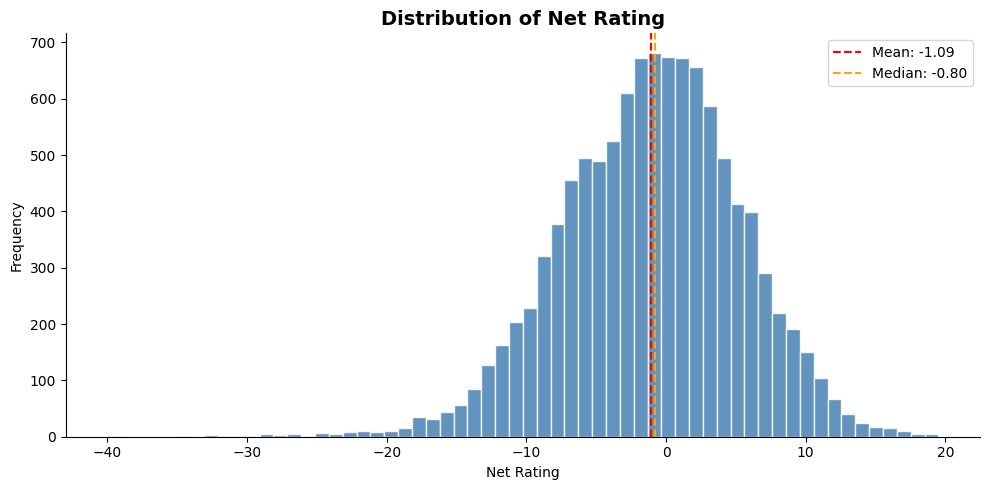

Saved.


In [9]:
# Distribution Plot 
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['net_rating'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df['net_rating'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Mean: {df['net_rating'].mean():.2f}")
ax.axvline(df['net_rating'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f"Median: {df['net_rating'].median():.2f}")

ax.set_title('Distribution of Net Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Net Rating')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/01_net_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")



### Observation
The distribution of net_rating has a mean of -1.09 and a median of -0.80, both sitting slightly 
below zero, which reflects the fact that bench and role players (who make up the majority of 
the dataset) tend to have a slightly negative team impact compared to starters. The distribution 
has a slight left skew (skewness = -0.325), meaning there are more extreme negative outliers 
than positive ones — some players hurt their teams significantly while elite performers are 
capped in how positive their rating can be. 57.3% of all player-seasons fall between -5 and +5, 
confirming that the bulk of the league is clustered near zero impact. The near-normal shape 
supports the use of OLS linear regression, which assumes normally distributed errors.


# Correlation Heatmap

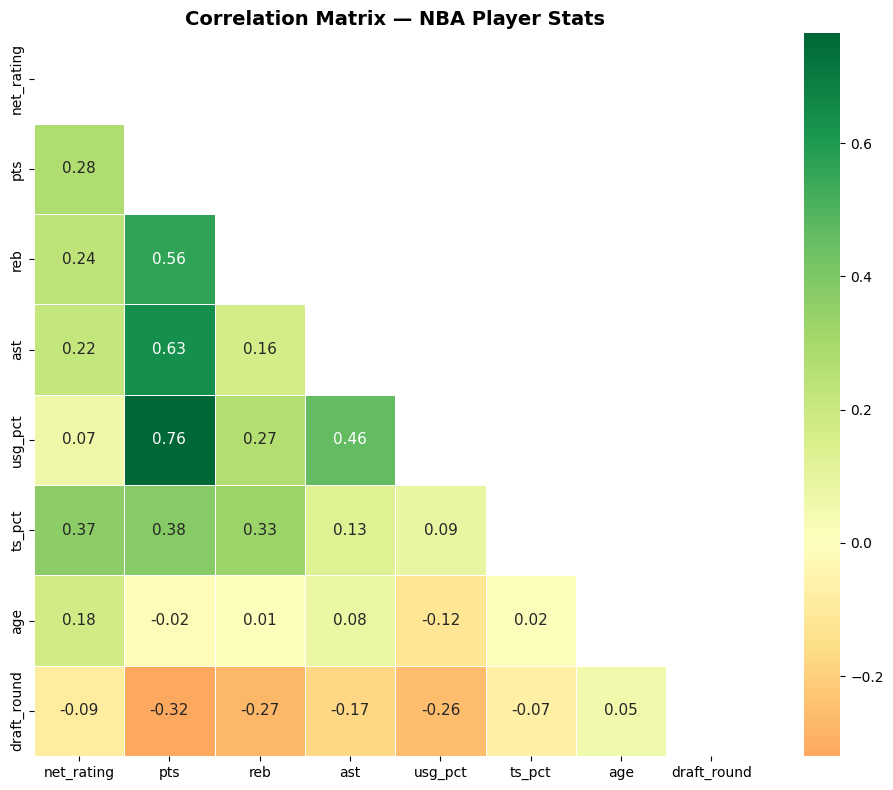

Saved.

Correlations with net_rating (sorted):
ts_pct         0.366
pts            0.278
reb            0.237
ast            0.215
age            0.178
usg_pct        0.072
draft_round   -0.088
Name: net_rating, dtype: float64


In [10]:
numeric_cols = ['net_rating','pts','reb','ast','usg_pct','ts_pct','age','draft_round']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, annot_kws={"size": 11})

plt.title('Correlation Matrix — NBA Player Stats', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

# Print top correlations with net_rating
print("\nCorrelations with net_rating (sorted):")
print(corr['net_rating'].drop('net_rating').sort_values(ascending=False).round(3))



### Observation
The three strongest predictors of net_rating are true shooting percentage (ts_pct, r = 0.37), 
points per game (pts, r = 0.28), and rebounds (reb, r = 0.24). This tells us that shooting 
efficiency is the single most important individual statistic for team impact — a player who 
shoots efficiently contributes more to winning than one who simply scores a lot. Assists (r = 0.22) 
and age (r = 0.18) also show moderate positive correlations, suggesting playmakers and experienced 
players tend to have better team impact. Notably, usg_pct shows a very weak correlation with 
net_rating (r = 0.07), meaning usage rate alone tells us almost nothing about a player's team 
impact — this motivates the inclusion of a pts × usg_pct interaction term in Model 3, since 
usage only matters when combined with efficiency. Draft_round has a slight negative correlation 
(r = -0.09), confirming that higher draft picks tend to have marginally better team impact on 
average.

# Scatter Plots

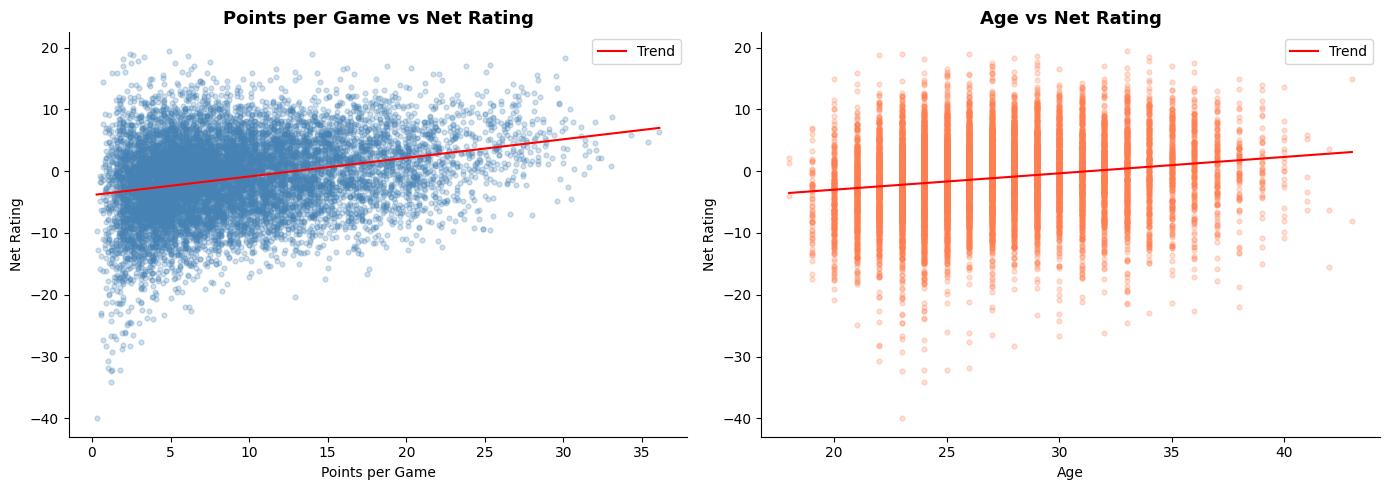

Saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: pts vs net_rating
axes[0].scatter(df['pts'], df['net_rating'], alpha=0.25, color='steelblue', s=12)
axes[0].set_title('Points per Game vs Net Rating', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Points per Game')
axes[0].set_ylabel('Net Rating')

# Add a trend line
m, b = np.polyfit(df['pts'], df['net_rating'], 1)
x_line = np.linspace(df['pts'].min(), df['pts'].max(), 100)
axes[0].plot(x_line, m*x_line + b, color='red', linewidth=1.5, label='Trend')
axes[0].legend()

# Plot 2: age vs net_rating
axes[1].scatter(df['age'], df['net_rating'], alpha=0.25, color='coral', s=12)
axes[1].set_title('Age vs Net Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Net Rating')

m2, b2 = np.polyfit(df['age'], df['net_rating'], 1)
x_line2 = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[1].plot(x_line2, m2*x_line2 + b2, color='red', linewidth=1.5, label='Trend')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/03_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")


### Observation
**Points vs Net Rating:** There is a weak positive relationship between points per game and 
net_rating (trend line slopes upward). Higher scorers tend to post better net ratings, but the 
extremely wide spread of points around the trend line — especially for low scorers — confirms 
that scoring volume alone is a poor predictor of team impact. A player scoring 5 points per game 
can have a net rating anywhere from -40 to +15, showing that context (team quality, role, 
efficiency) matters far more than raw scoring.

**Age vs Net Rating:** The age plot shows a very slight positive slope, but the vertical banding 
pattern reveals that ages are recorded as whole numbers, and at every single age the spread of 
net ratings is enormous — from -40 to +15. This means age has almost no predictive power for 
net_rating individually. Veteran players (35+) show slightly less extreme negative outliers, 
possibly because only the best older players remain in the league, creating a survivorship bias 
in the data.

# Boxplots

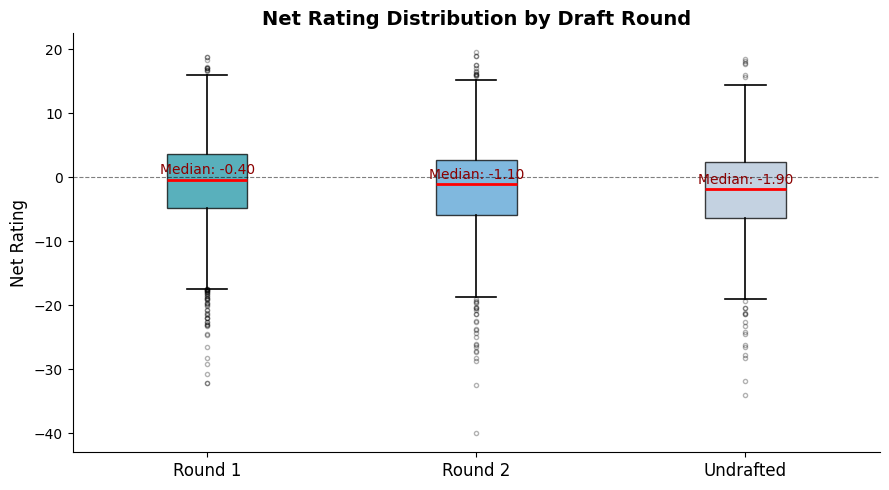

Saved.


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
 
# Group data
groups = [
    df[df['draft_round'] == 1]['net_rating'],
    df[df['draft_round'] == 2]['net_rating'],
    df[df['draft_round'] == 3]['net_rating'],   # 3 = Undrafted
]
labels = ['Round 1', 'Round 2', 'Undrafted']
colors = ['#2196a6', '#56a0d3', '#b0c4d8']
 
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.3, color='gray'))
 
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
 
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Net Rating', fontsize=12)
ax.set_title('Net Rating Distribution by Draft Round', fontsize=14, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
 
# Annotate medians
for i, g in enumerate(groups, 1):
    ax.text(i, g.median() + 0.4, f'Median: {g.median():.2f}',
            ha='center', va='bottom', fontsize=10, color='darkred')
 
plt.tight_layout()
plt.savefig('../outputs/04_net_rating_by_draft_round.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")
 

# Observation - 
Round 1 picks have the highest median net_rating, followed by Round 2, and Undrafted players show the lowest median and widest spread. 
This confirms that draft position serves as a reasonable proxy for baseline talent level —
 higher-drafted players are placed in better team environments and given roles
that allow them to contribute positively. The wide IQR across all three groups
reinforces that draft round alone is a weak predictor of net_rating, motivating its inclusion as a control variable rather than a primary predictor.

# Outlier Detection

In [15]:
Q1 = df['net_rating'].quantile(0.25)
Q3 = df['net_rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['net_rating'] < lower_bound) | (df['net_rating'] > upper_bound)

print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f} | Upper bound: {upper_bound:.2f}")
print(f"\nTotal outliers: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}% of data)")

print("\n--- Top 10 HIGH outliers (best net_rating) ---")
high_out = df[outlier_mask & (df['net_rating'] > 0)][['player_name','season','net_rating','pts','gp']].nlargest(10,'net_rating')
print(high_out.to_string(index=False))

print("\n--- Top 10 LOW outliers (worst net_rating) ---")
low_out = df[outlier_mask & (df['net_rating'] < 0)][['player_name','season','net_rating','pts','gp']].nsmallest(10,'net_rating')
print(low_out.to_string(index=False))


Q1: -5.30 | Q3: 3.20 | IQR: 8.50
Lower bound: -18.05 | Upper bound: 15.95

Total outliers: 112 (1.0% of data)

--- Top 10 HIGH outliers (best net_rating) ---
     player_name  season  net_rating  pts  gp
     James Jones 2013-14        19.5  4.9  20
  Draymond Green 2015-16        18.9 14.0  81
    KJ McDaniels 2015-16        18.9  2.4  37
    Jimmy Butler 2011-12        18.8  2.6  42
    JaVale McGee 2016-17        18.7  6.1  77
Boban Marjanovic 2022-23        18.5  3.3  31
   Stephen Curry 2015-16        18.3 30.1  79
  Devontae Cacok 2020-21        18.1  2.0  20
     Ben Wallace 2008-09        17.9  2.9  56
  John Lucas III 2011-12        17.7  7.5  49

--- Top 10 LOW outliers (worst net_rating) ---
        player_name  season  net_rating  pts  gp
        Erik Murphy 2013-14       -40.0  0.3  24
       Juwan Morgan 2020-21       -34.1  1.2  29
       Bruno Sundov 2002-03       -32.4  1.2  26
    Hasheem Thabeet 2011-12       -32.2  1.8  20
       Mitch McGary 2015-16       -32.2  1.


### Observation
Using the IQR method, outliers are defined as net ratings below -18.05 or above +15.95. Only 
112 player-seasons (1.0% of the data) are classified as outliers, confirming that extreme values 
are rare but significant.

The high outliers reveal an important pattern — players like James Jones (19.5), KJ McDaniels 
(18.9), and Jimmy Butler (18.8) posted extreme positive net ratings despite scoring very few 
points (4.9, 2.4, and 2.6 respectively). This happens because these players played limited 
minutes on exceptional teams — their net rating reflects their team's dominance rather than 
their individual brilliance. Stephen Curry (18.3) is the only high outlier who was genuinely 
elite individually, scoring 30.1 points per game on the historically great 2015-16 Warriors.

The low outliers tell the opposite story — Erik Murphy (-40.0), Juwan Morgan (-34.1), and 
Bruno Sundov (-32.4) all scored under 2 points per game in very few games (20-29 gp), meaning 
their catastrophic net ratings are driven entirely by small sample size on poor teams rather 
than genuine individual failure. This confirms that net_rating is heavily influenced by team 
context and sample size, which is a key limitation the model cannot fully account for. The 
sensitivity analysis in Section 6 will test whether removing these 112 outliers meaningfully 
changes the model coefficients.